# Notebook 1: Exploratory Data Analysis (EDA)

In [1]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import resample
from pathlib import Path
from common.paths import ROOT

In [2]:
df = pd.read_csv(ROOT/'data/creditcard.csv') # Load Data
df.head(5) # Display first 5 rows

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


/var/folders/h3/p77jbj7s6sqcr8q3jrnhr9qw0000gn/T/ipykernel_83434/442517135.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(('Not Fraud', 'Fraud')) # Class == 0 => Not Fraud, Class == 1 => Fraud


Text(0.5, 1.0, 'Fraudulent vs Non-fraudulent Transactions')

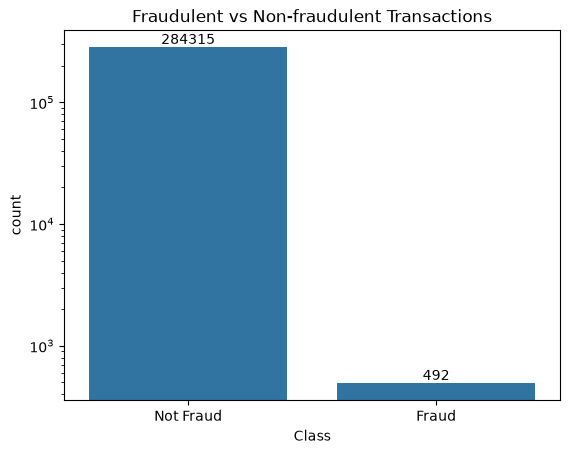

In [4]:
ax = sns.countplot(df, x = 'Class')
ax.set_xticklabels(('Not Fraud', 'Fraud')) # Class == 0 => Not Fraud, Class == 1 => Fraud
ax.set_yscale('log')
ax.bar_label(ax.containers[0]) # Label top of each bar with count
ax.set_title('Fraudulent vs Non-fraudulent Transactions')

In [5]:
fraudulent_count, nonfraudulent_count = 492, 284315
fraudulent_percentage = round(100* fraudulent_count/(fraudulent_count + nonfraudulent_count),2)
print(f"{fraudulent_percentage}% of cases a fraudulent") 

0.17% of cases a fraudulent


The Credit Card dataset consists of 284K+ transactions across two days. 

The known feature columns are:
- Time (seconds)
- Amount (USD)
- Class (1 for fraudulent, 0 for non-fraudulent)

There are also 28 PCA-anonymised feature columns, labeled V1-V28.

The dataset contains 492 fraudulent cases in total (0.17%).

In [6]:
# Apply Column transformations for EDA
df["Amount_log"] = np.log1p(df["Amount"])
df['Time_hour'] = (df['Time'] % 86400)/ 3600

The mean transaction and median transaction 'Amount' is $88.35 and $22.00 respectively. However, the maximum transaction 'Amount' is $25,691.16, which shows that there is a strong positive (left-side) skew. Therefore, we apply a log1p transformation so that this distribution is easier to visualise.

We apply a transformation to the 'Time' column, which allows us to compare transactions based on the time of day.


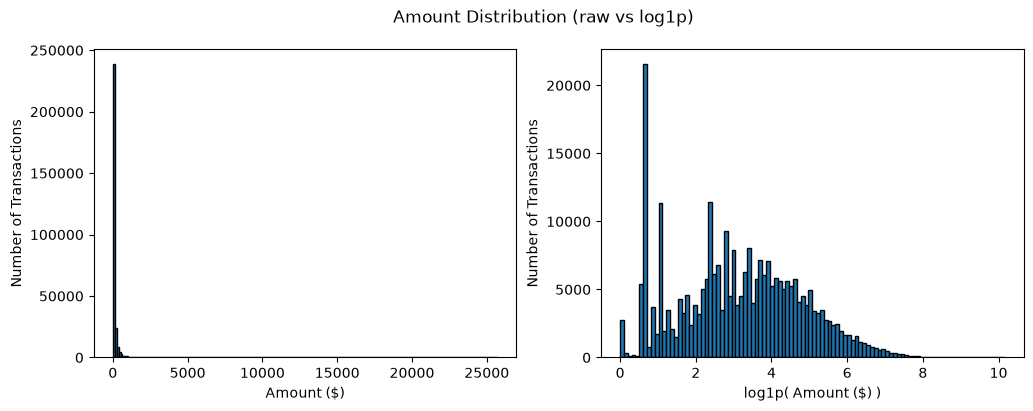

In [7]:
# Show the amount distribution (raw vs log1p side by side)
fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
fig.suptitle('Amount Distribution (raw vs log1p)')
ax1.set_xlabel('Amount ($)')
ax1.set_ylabel('Number of Transactions')
ax1.hist(df['Amount'], orientation= 'vertical', bins=200, edgecolor = 'black')

ax2.set_xlabel('log1p( Amount ($) )')
ax2.set_ylabel('Number of Transactions')
ax2.hist(df['Amount_log'], orientation= 'vertical', bins=100, edgecolor = 'black');

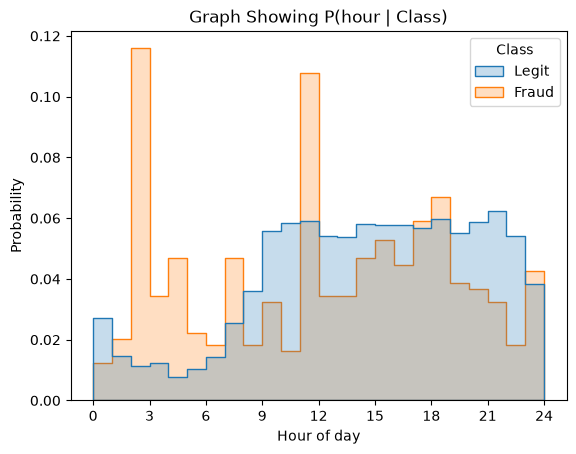

In [8]:
plot_df = df.assign(Class=df["Class"].map({0: "Legit", 1: "Fraud"}))
ax = sns.histplot(data=plot_df, x="Time_hour", hue="Class",  bins=24,
             stat="probability",common_norm=False, element="step");
ax.set(
    title = 'Graph Showing P(hour | Class)',
    xlabel = 'Hour of day',
    xticks = range(0,25,3),
);   

In [9]:
hourly = df.groupby(df["Time_hour"].astype(int)).agg(
    volume=("Class", "size"), # transactions that hour
    fraud_count = ("Class", "sum"), # fraudulent transactions that hour
    fraud_rate = ("Class", "mean"),  # (fraud/transaction) that hour
)

hourly

,volume,fraud_count,fraud_rate
Time_hour,,,
0,7695,6,0.000780
1,4220,10,0.002370
2,3328,57,0.017127
3,3492,17,0.004868
4,2209,23,0.010412
5,2990,11,0.003679
6,4101,9,0.002195
7,7243,23,0.003175
8,10276,9,0.000876


## Conclusion: 

- 'Amount' is heavily right-skewed, so we shall use log1p
- The Fraud rate varies by hour of day, so we shall derive hour_of_day from 'Time'
- There is a huge imbalance, with only 0.17% of transactions being fraudulent
    - We shall set contamination rate to ~ 0.0017
    - We shall use a stratified split
    - We shall use Precision and Recall as our model evaluation metrics
